# CHURN MODEL

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [3]:
df= pd.read_csv(r"C:\Users\DELL\Downloads\credit_risk_dataset.csv")

In [4]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1
...,...,...,...,...,...,...,...,...
995,53,44519.0,7307,433,22,PhD,Rent,1
996,22,107487.0,44901,582,7,High School,Own,1
997,34,102870.0,16205,372,29,Masters,Rent,0
998,60,66197.0,10906,780,24,PhD,Own,0


In [5]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Income            985 non-null    float64
 2   Loan_Amount       1000 non-null   int64  
 3   Credit_Score      1000 non-null   int64  
 4   Employment_Years  1000 non-null   int64  
 5   Education_Level   1000 non-null   object 
 6   Housing_Status    1000 non-null   object 
 7   Default           1000 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


np.int64(0)

In [6]:
df.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
df['Default'].value_counts()

Default
0    862
1    138
Name: count, dtype: int64

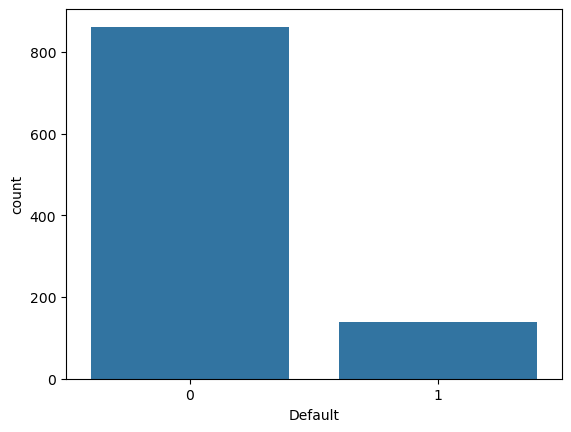

In [9]:
sns.countplot(x='Default',data=df)
plt.show()

In [10]:
df.isnull().sum().sum()

np.int64(0)

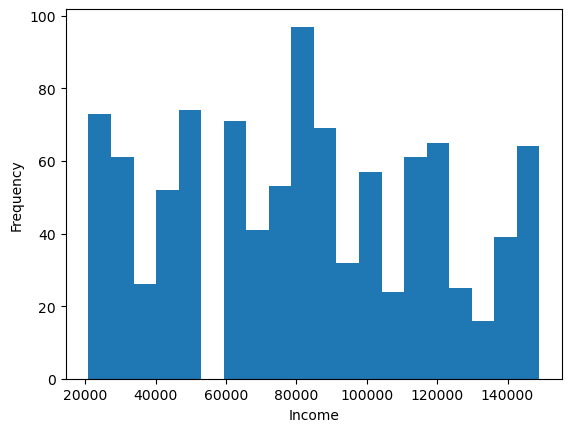

In [11]:
plt.hist(df['Income'], bins=20)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [12]:
df['Education_Level'].unique()
df['Housing_Status'].unique()

array(['Own', 'Rent', 'Mortgage'], dtype=object)

In [13]:
df=pd.get_dummies(df,columns=['Education_Level','Housing_Status'],drop_first=True)

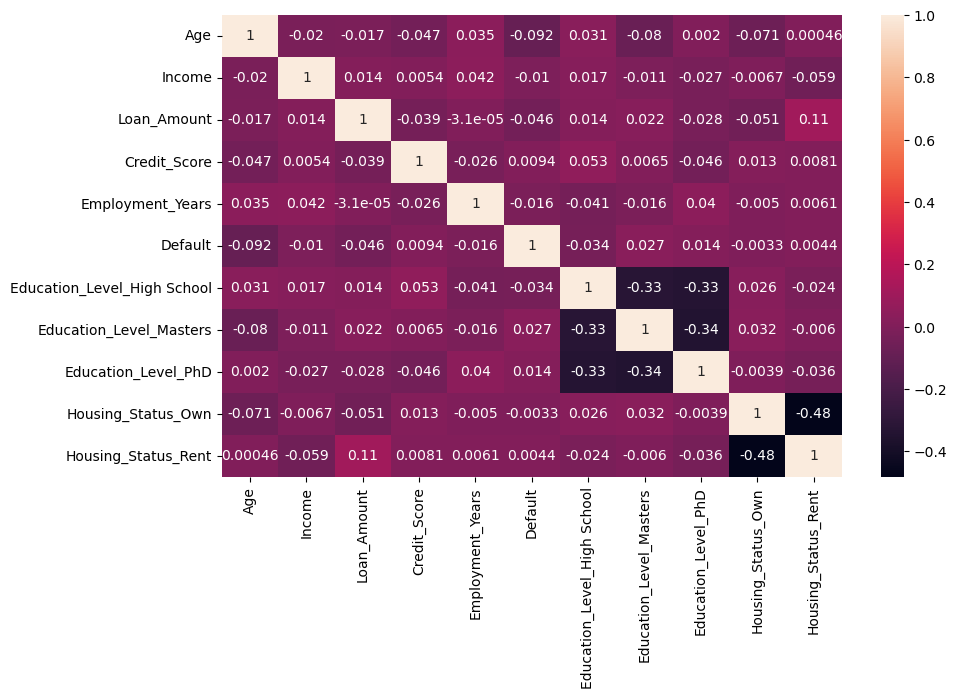

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

In [14]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,59,52154.0,11276,823,15,0,False,False,False,True,False
1,49,116646.0,43663,315,5,0,False,False,True,True,False
2,35,61157.0,18994,428,8,1,False,True,False,True,False
3,63,52154.0,28499,408,26,0,False,False,False,False,True
4,28,148876.0,28040,832,3,1,False,True,False,True,False


In [17]:
X = df.drop('Default', axis=1)
y = df['Default']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
X_train.shape

X_test.shape

y_train.shape

y_test.shape

(200,)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
pred_lr = lr.predict(X_test)

In [25]:
y_pred = lr.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)*100

86.0